# Prédiction de la druggabilité de poches protéiques

Les poches protéiques constituent les régions structurales susceptibles d'accueillir des ligands. Leur composition physicochimique, leur taille et leur géométrie peuvent être liées à leur capacité à fixer un candidat médicament, c'est-à-dire à leur druggabilité.

Dans ce projet on cherche à déterminer **si les descripteurs d'une poche ligand-based permettent de prédire sa druggabilité**.

- Autrices: Laurédane Coustillas, Farah-Luna Gonzalez, Anna Perova
- Étudiantes de M2 BI-ISDD - Modélisation des macromolécules
- Date: 21/09/2026 - 26/09/2026

- Étapes:
    1. Pré-processing & Analyse de dataset
    2. Clustering
    3. Bootstrap
    4. CART pour minimiser l'erreur
    5. RF et Gradiant Boosting
    6. PLS ou PLSDA

- Info sur dataset:
    - L'ensemble de données a été extrait du jeu de données de Krasowski et contient 400 poches :
        - 316 poches druggables,
        - 84 poches moins druggables.

Decrit selon 19 variables:
-   descripteurs quantitatifs de la géométrie de la poche: `hydrophobic_kyte`, `p_hydrophobic_residue`, `p_polar_residues`, `p_aromatic_residues`, `p_aliphatic_residues`, `p_Otyr_atom`,  `p_NE2_atom`, `p_Nlys_atom`, `p_Ntrp_atom`, `p_Ooh_atom`, `p_ND1_atom`,  `SURFACE_HULL`, `DIAMETER_HULL`, `VOLUME_HULL`, `SMALLEST_SIZE`,  `RADIUS_CYLINDER`, `C_RESIDUES`, `NumAtoms_atm`, `Radius_of_gyration_atm`;
-   descripteurs qualitatif: `Shape` (4 types/facteurs: Sphere, Disk, Strongly anisotropic, Rod) d'après *Ziani et al., 2026*;

Variables à prédire: 
-   Druggabilité (qualitative) = le type de druggabilité de chaque poche : 1 = druggable, 0 = moins druggable (Col 24);
-   Score_Drugg (quantitative) = score de druggabilité (Col 3).


- Packages utilisés:
    - `FactoMineR`,
    - `factoextra`,
    - `corrplot`,
    - `gplots`,
    - `pheatmap`,
    - `caret`,
    - `pROC`,
    - `fmsb`,
    - `rpart`,
    - `MASS`,
    -`rpart.plot`,
    - `randomForest`, 
    - `dplyr`


### Partie 0. Préparation

#### 1. Intallation des packages et chargement du dataset

In [28]:
required_packages <- c("FactoMineR","factoextra","corrplot","gplots",
"pheatmap","caret","pROC","fmsb","rpart","MASS","rpart.plot","randomForest", "dplyr")
lapply(required_packages, require, character.only = TRUE)

file <- read.csv("data.csv")
glimpse(file)
dim(file)
# Vérifier si les NA sont présents
file_na <- na.omit(file)
dim(file_na)
# Transformer la variable `Shape` en factor
file_na$Shape <- as.factor(file_na$Shape)

Rows: 400
Columns: 23
$ PDB_ID                 <chr> "PDB1", "PDB2", "PDB3", "PDB4", "PDB5", "PDB6", "PDB7", "PDB8", "PDB9", "PDB10", "PDB1…
$ Ligand_Num             <int> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24,…
$ Score_Drugg            <dbl> 0.66, 0.91, 0.94, 0.65, 0.83, 0.92, 1.00, 0.81, 0.77, 0.03, 0.94, 0.96, 0.46, 0.68, 0.…
$ hydrophobic_kyte       <dbl> -0.48, 0.22, -0.17, -0.79, 0.01, 0.03, 1.38, -0.02, -0.02, -2.62, 0.28, 0.34, -0.45, -…
$ p_hydrophobic_residues <dbl> 0.62, 0.83, 0.82, 0.50, 0.76, 0.78, 0.90, 0.65, 0.72, 0.42, 0.80, 0.57, 0.61, 0.65, 0.…
$ p_polar_residues       <dbl> 0.59, 0.56, 0.45, 0.57, 0.52, 0.52, 0.33, 0.58, 0.44, 0.92, 0.30, 0.43, 0.48, 0.62, 0.…
$ p_aromatic_residues    <dbl> 0.16, 0.17, 0.36, 0.29, 0.12, 0.13, 0.27, 0.12, 0.08, 0.33, 0.20, 0.24, 0.04, 0.23, 0.…
$ p_aliphatic_residues   <dbl> 0.19, 0.39, 0.14, 0.14, 0.28, 0.26, 0.30, 0.12, 0.24, 0.00, 0.20, 0.24, 0.17, 0.15, 0.…
$ p_Otyr_atom            <

#### 2. Ajouter la variable à prédire : Druggabilité 
- Si `Score_Drugg` > 0.5 -> "Druggable"
- Sinon: "Non-Druggable"

In [29]:
file_na$druggable <- if_else(file$Score_Drugg > 0.5, "Druggable", "Non-Druggable")

#### 3. Mise à l'échelle
- Énlèver la variable `Score_Drugg`et autres variables non-numeriques pour mettre les numeriques à l'échelle
- Faire un plot avant/après pour comparer

In [37]:
data_num_shape <- file_na %>% select(-c(1,2,3,24)) #à utiliser pour CART (raw)
Y_drugg <- file_na$druggable #a utiliser pour CART comme Y
data <- file_na[4:22] #seulement les valeurs numeriques, a utiliser pour la suite (PCA, hclust, bootstrap)
data$druggable <- file_na$druggable

*Observations: `SURFACE_HULL` et `VOLUME_HULL` sont les plus importants due à la difference des unités avec le reste des variables; Le `scale()` permet de tous normaliser. On note un outlier pour `p_Nlys_atom`, c'est possible qu'il faut l'énlever.*

#### 4. Vérification de correlations entre le variables & Plot la matrice de correlations

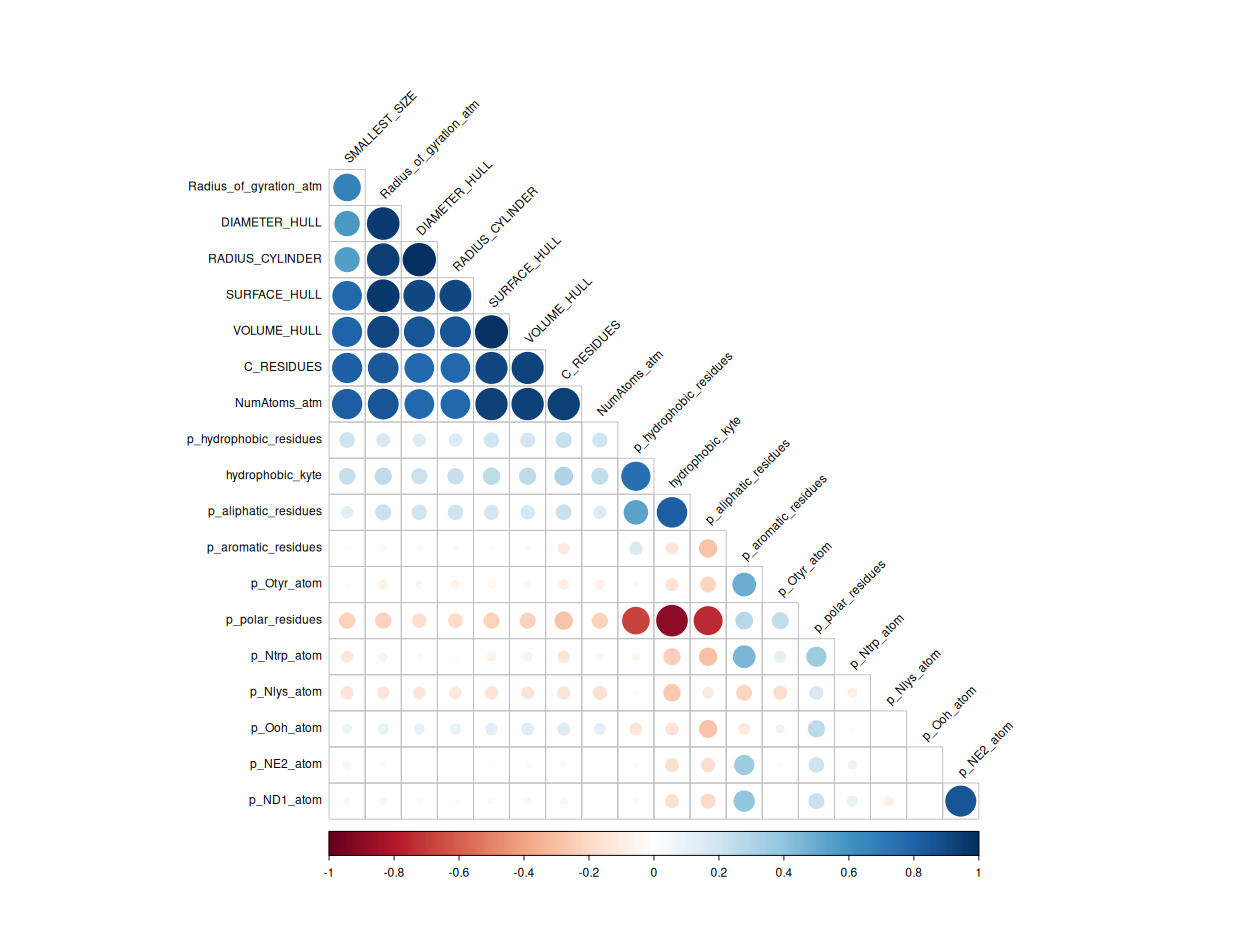

In [31]:
corr_matrix <- cor(data)
corrplot(corr_matrix, 
         method = "circle",     
         type = "lower",        
         order = "hclust",      
         tl.col = "black",      
         tl.srt = 45,           
         tl.cex = 0.8,          
         diag = FALSE)


#### 5. Vérifier si les variances sont proches à zero

In [19]:
nearZeroVar(data_s, saveMetrics = TRUE)

                       freqRatio percentUnique zeroVar   nzv
hydrophobic_kyte        1.200000         59.75   FALSE FALSE
p_hydrophobic_residues  1.130435         14.25   FALSE FALSE
p_polar_residues        1.933333         17.25   FALSE FALSE
p_aromatic_residues     1.526316         12.25   FALSE FALSE
p_aliphatic_residues    1.263158         12.50   FALSE FALSE
p_Otyr_atom             1.395161          1.50   FALSE FALSE
p_NE2_atom              2.525253          1.25   FALSE FALSE
p_Nlys_atom             1.887931          1.75   FALSE FALSE
p_Ntrp_atom             3.958333          1.50   FALSE FALSE
p_Ooh_atom              1.130841          2.25   FALSE FALSE
p_ND1_atom              2.436893          1.25   FALSE FALSE
SURFACE_HULL            2.000000         99.75   FALSE FALSE
DIAMETER_HULL           1.000000         86.75   FALSE FALSE
VOLUME_HULL             1.000000        100.00   FALSE FALSE
SMALLEST_SIZE           1.000000         77.00   FALSE FALSE
RADIUS_CYLINDER         


### Partie 1. Analyse Non-Supervisée (Clustering)

Deux méthodes de classification etudié:

- classification hiérarchique
- kmeans

Functions used here: 
 - `scale()` = normalization of data
 - `dist()` = distance matrix calculation
 - `hclust()` = calculation of the classification tree 
 - `plot()` = graphical representation of the classification tree
 - `fviz_nbclust`(factoextra) = determination of the optimal number of clusters according to a chosen criterion
 - `rect.hclust()` = visualization of clusters on the classification tree
 - `cutree()` = cluster retrieval

#### 1.1. Separer les échantillons d'entrainement et d'apprentissage

In [39]:
# Split Train/Test
set.seed(123)
# On utilise `createDataPartition()` de caret pour stratifier les données non-equilibrées
train_idx <- createDataPartition(data$druggable, p=0.75, list = FALSE)
train_set <- data[train_idx, ]
test_set <- data[-train_idx, ]

#save the folds for cross-validation (and CART and RegLog)
folds <- createFolds(train_set$druggable, k = 10, list = TRUE)


#### 1.2. Mise à l'échelle du test et train SEPAREMENT

In [49]:
train_s <- scale(train_set[-20])
train_df <- as.data.frame(train_s)
test_s <- scale(test_set[-20], center=attr(train_s, "scaled:center"), scale=attr(train_s, "scaled:scale"))
test_df <- as.data.frame(test_s)

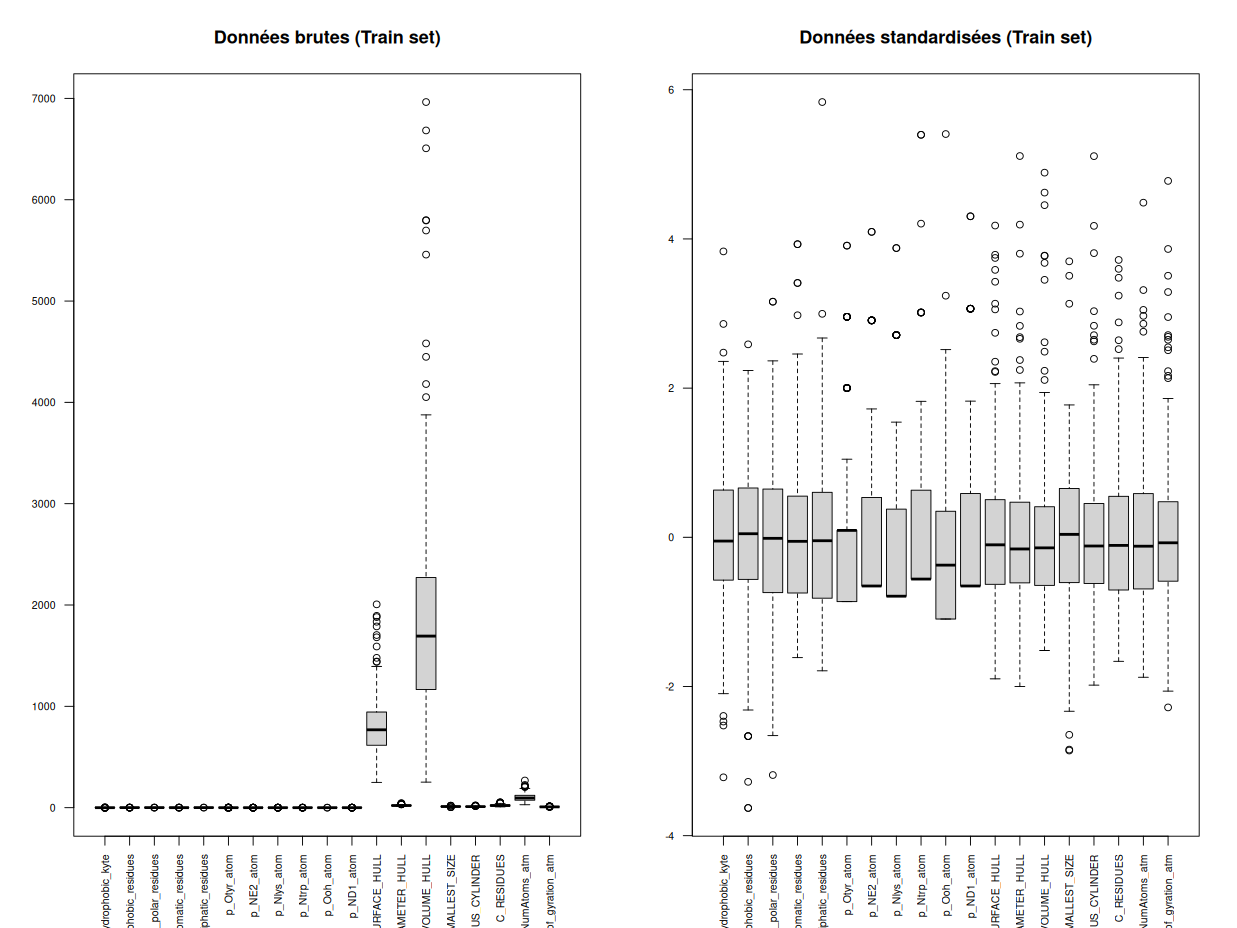

In [53]:
par(mfrow = c(1, 2))
boxplot(train_set[-20], main = "Données brutes (Train set)", las = 2, cex.axis = 0.7)
boxplot(train_df, main = "Données standardisées (Train set)", las = 2, cex.axis = 0.7)
par(mfrow = c(1, 1))

#### 1.3. Clustering (CAH et/ou k-means) sur TRAIN

##### 1.3.1.Classification Ascendante Hiérarchique (CAH)

In [54]:
#on scaled data! (without drugg col)
#dist() function!
trains.euc <- dist(train_df, method = "euclidean")

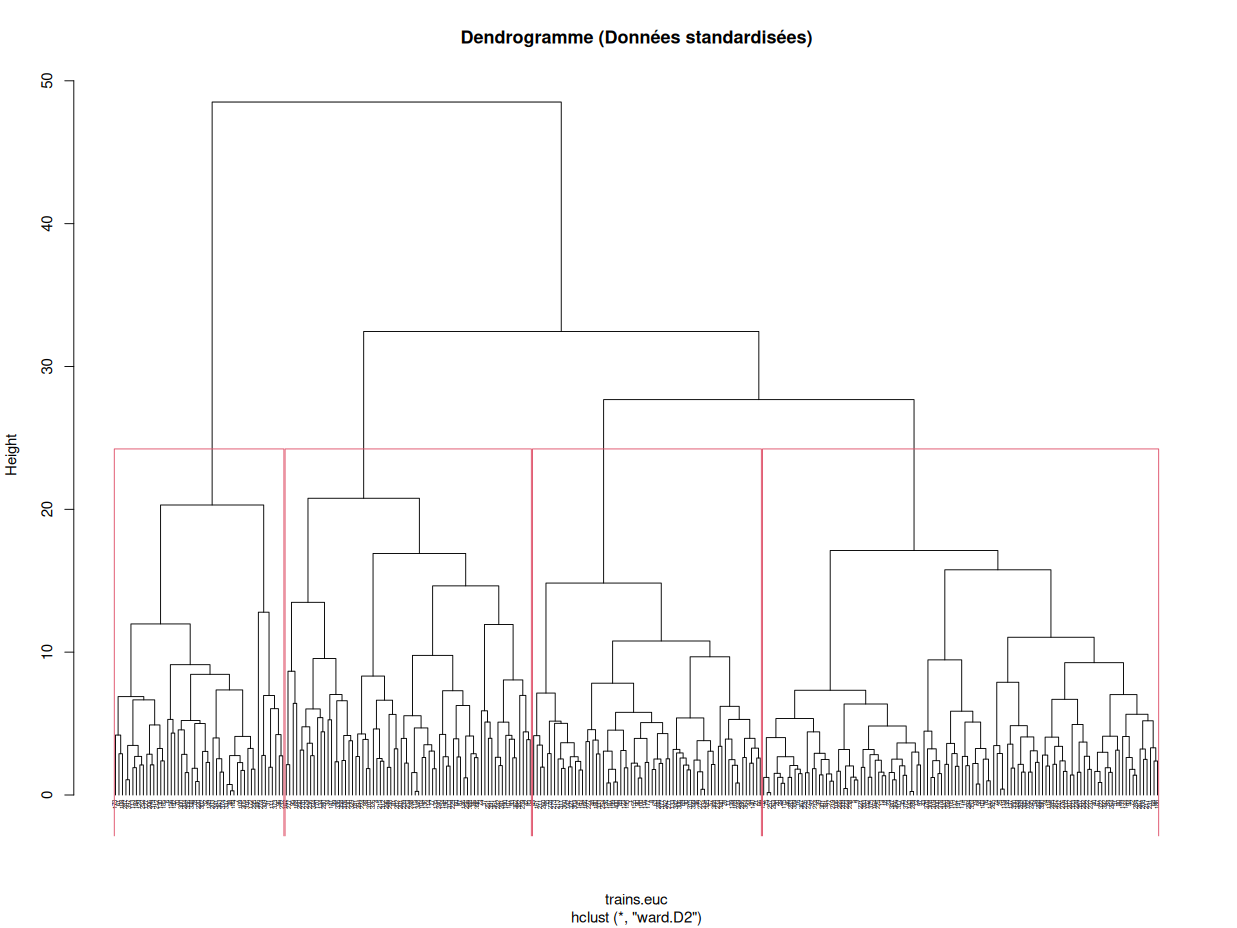

In [ ]:
#we use scaled data; wardD2 method = minimizes the intra variability of the clusters and maximizes the inter variability (between clusters)

train_s_hca <- hclust(trains.euc, method = "ward.D2")

#plot the dendrogram
plot(train_s_hca, hang = -1, cex = 0.4, main = "Dendrogramme (Données standardisées)")
rect.hclust(train_s_hca, k = 4)

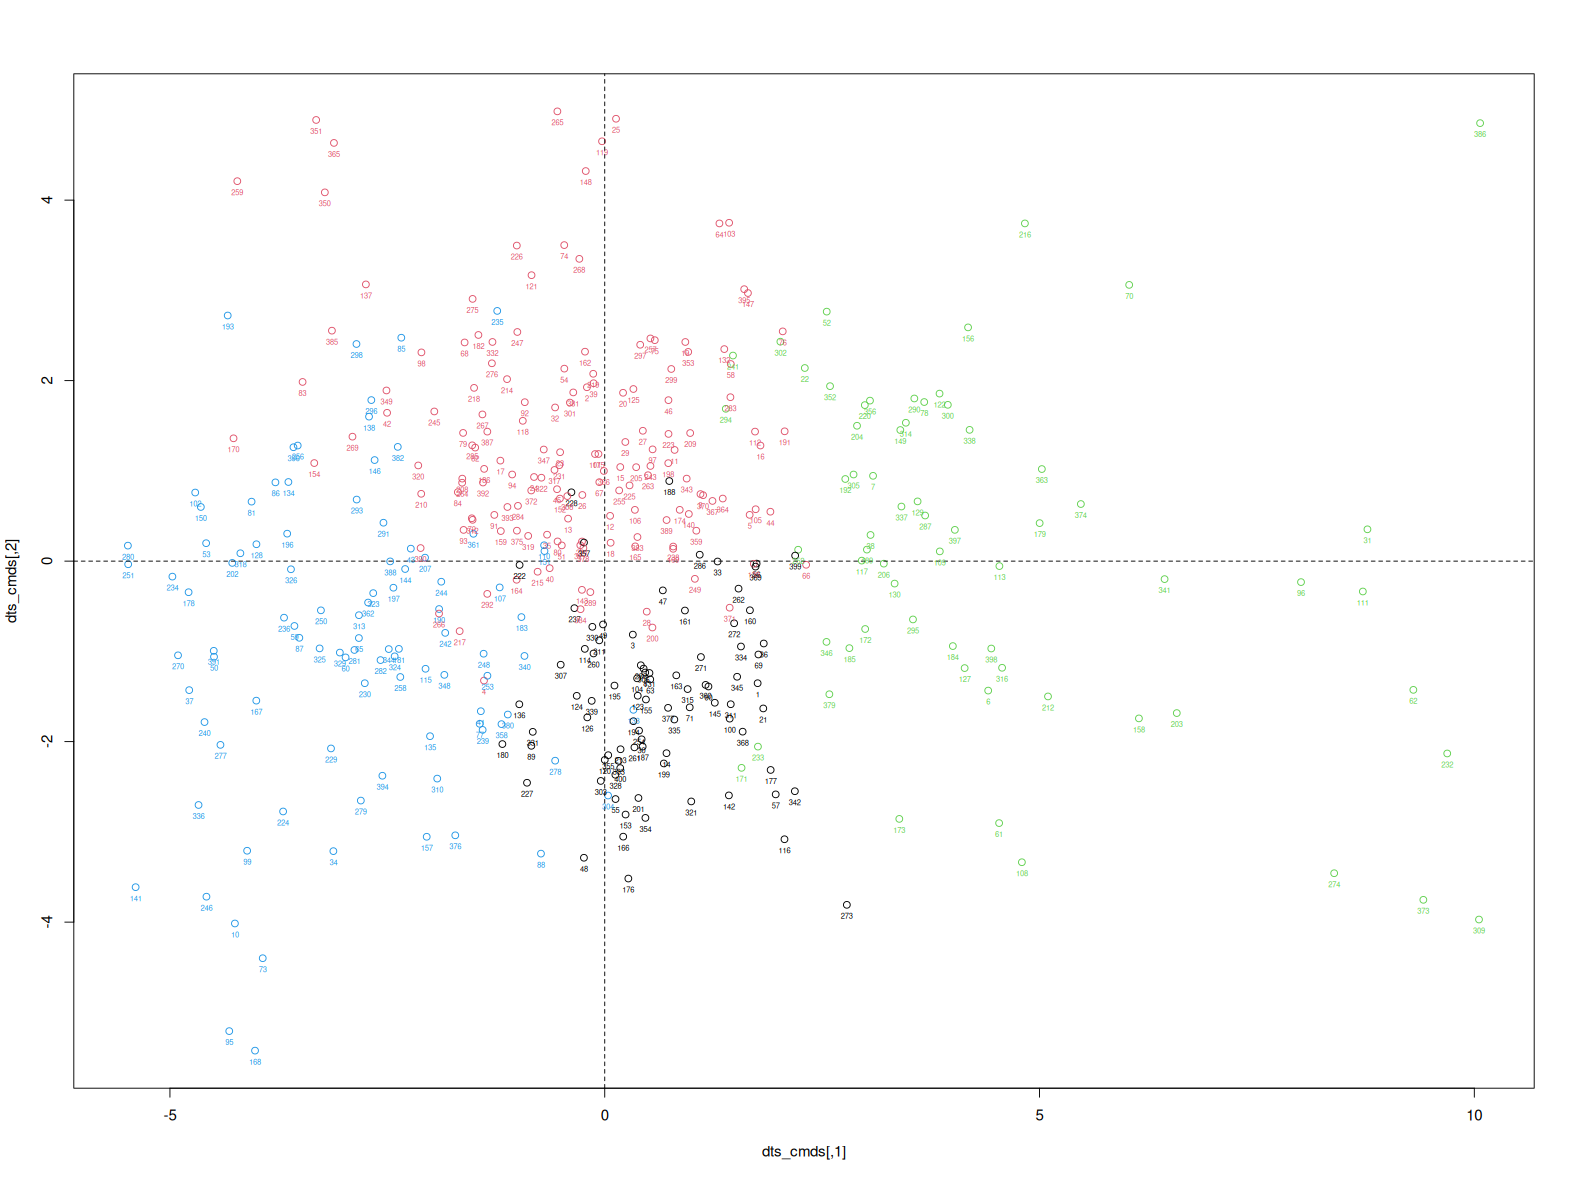

integer(0)

In [25]:
dts.cluster <- cutree(data_s_hca, k = 4)
dts_cmds <- cmdscale(dts.euc)

plot(dts_cmds, col = dts.cluster) + 
abline(h = 0, v = 0, lty = 2) +
text(dts_cmds, labels = rownames(data_s), cex = 0.5, pos = 1, col = dts.cluster)


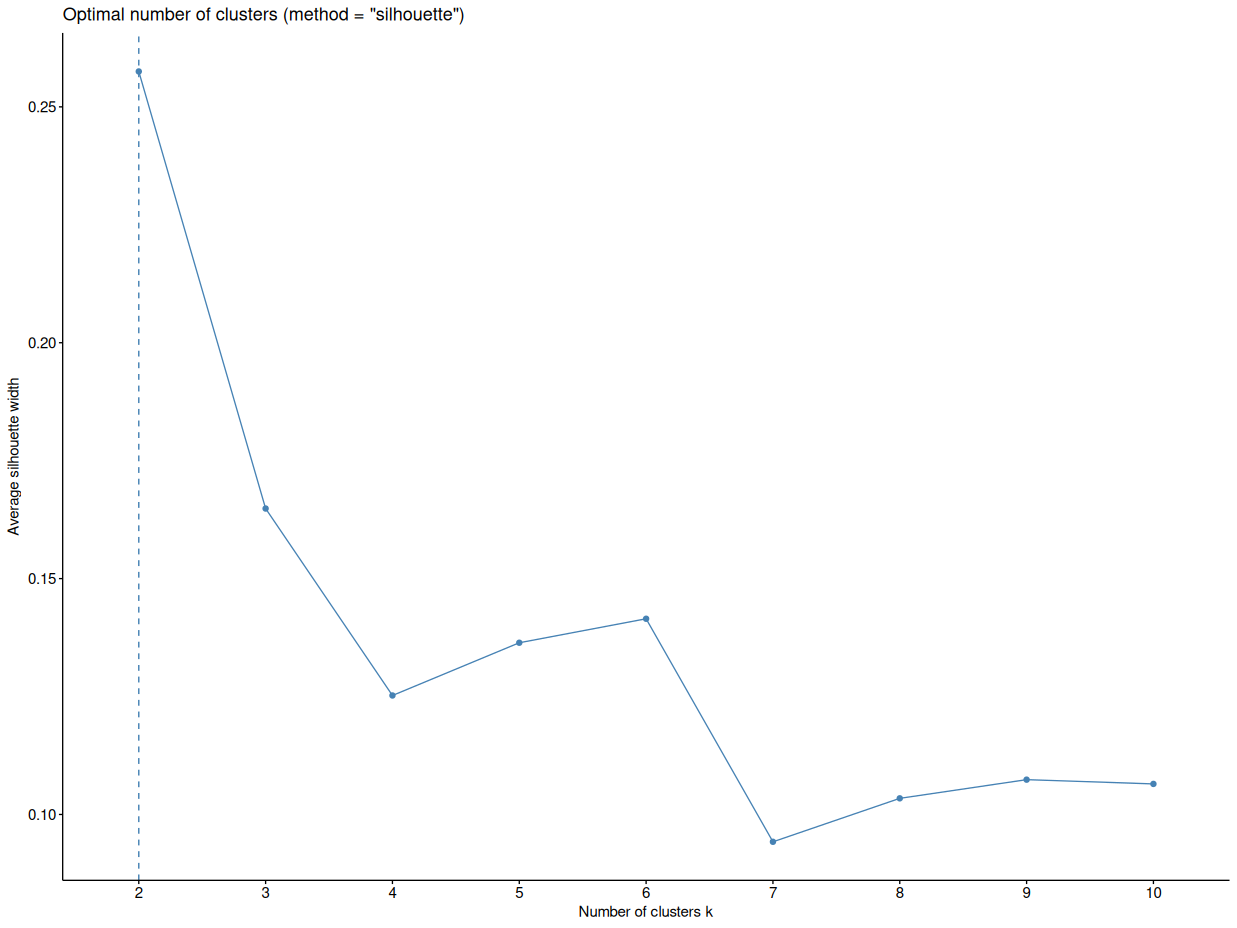

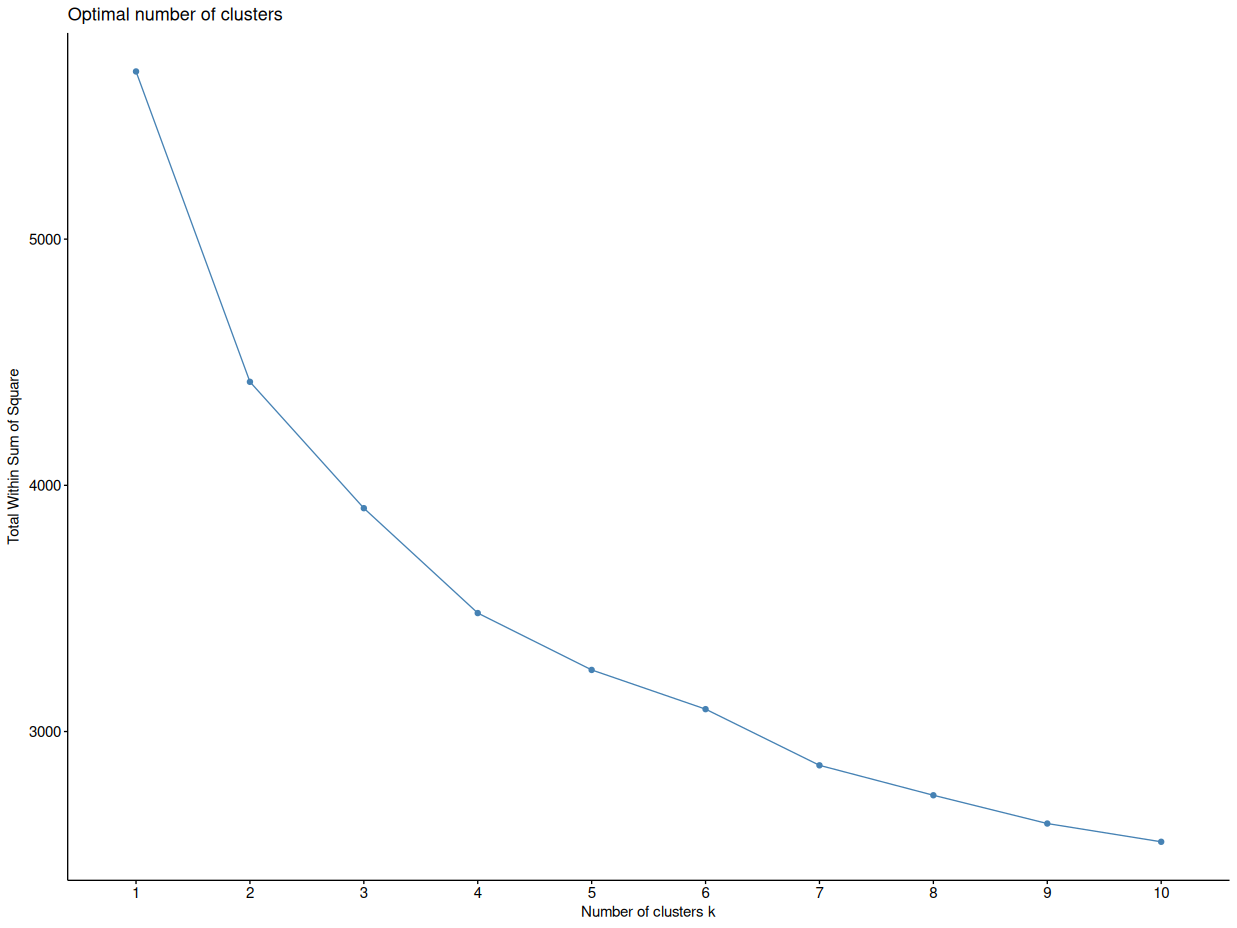

In [57]:
fviz_nbclust(train_df,
             hcut,
             method = "silhouette")

fviz_nbclust(train_df, kmeans, method="wss")
#takes into argument the data (not the dist matrx)
#observes the evolution of intra-cluster variability as a function of the number of clusters to determine the optimal number of clusters
#FUNcluster option = hcut

*Quel nombre de cluster allez-vous choisir ? Pourquoi ?*

In [69]:
#cutree() function!
#retrieves for each individual (protein pockets) their cluster
group_hclust <- factor(cutree(train_s_hca, k = 4))
table(group_hclust)

group_hclust
  1   2   3   4 
 66  71 114  49 

#### 1.4. APC sur TRAIN 

0. scale data
1. calculate covatiance matrix
2. calculate the eigenvalues
3. calculate principal components
3. reverse the signs of eigenvalues (point to the negative)
4. visualize

Ben's better biplot. Type bb_info() in the R console for help and info.


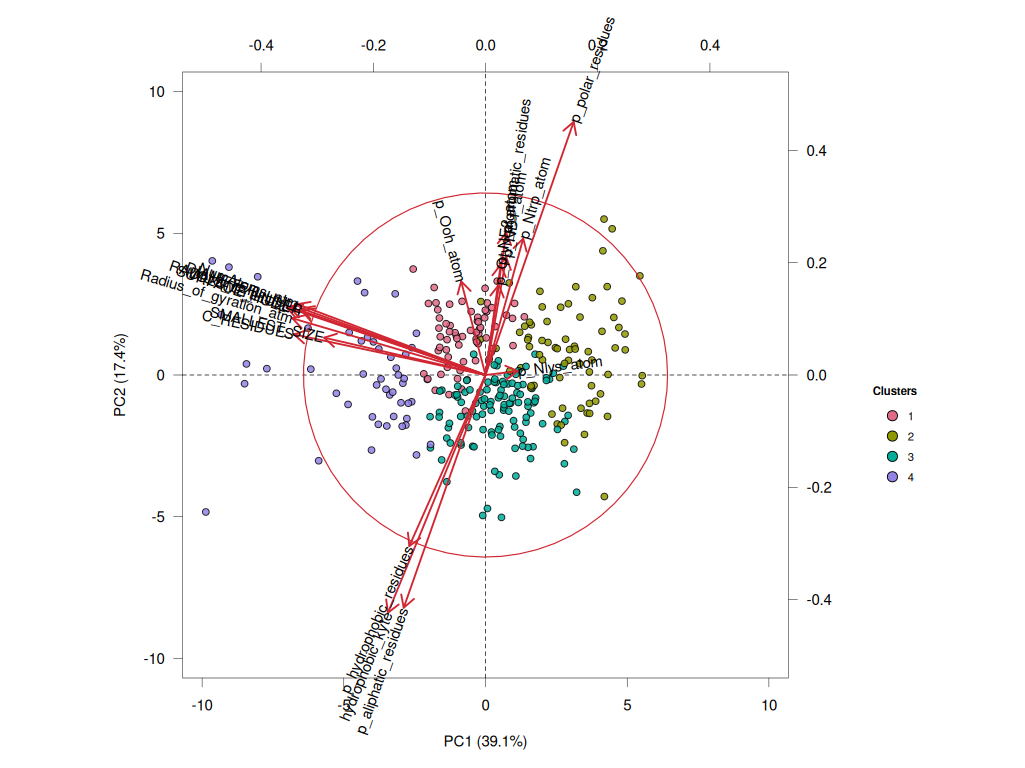

In [70]:
# Load bb_biplot script from Github
source("https://raw.githubusercontent.com/benbell95/better_biplot/refs/heads/main/r/better_biplot.r")

pca_res <- prcomp(train_df, scale = TRUE)
gr <- group_hclust
pca_res$rotation <- -1*pca_res$rotation
head(pca_res$rotation)

pca_res$x <- -1*pca_res$x
head(pca_res$x)



bb_biplot(pca_res, scale=0, group=gr, lab_rotation=TRUE, circle.eq=TRUE, legend=TRUE, title.leg="Clusters")

In [130]:
#exctract frist two components for hclustering with bootstrap sampling
pc_scores <- pca_res$x[, 1:3]
pc_df <- as.data.frame(pc_scores)

#### 1.5. Bootstrap

L'idée : si nos clusters constituent une caractéristique réelle des données, ils devraient réapparaître de manière cohérente lors de différents rééchantillonnages. Si un cluster est un artefact dû à quelques points influents, il disparaîtra, fusionnera avec un autre cluster ou sa composition changera en fonction des points rééchantillonnés. Le bootstrap vise à tester la stabilité : « Obtiendrais-je les mêmes clusters avec des données légèrement différentes ? »

`clusterboot()` utilise l'index de Jaccard pour comparer la similitude des clusters de début contre les clusters de rééchantillonnage.
Un cluster avec un indice de Jaccard moyen d'environ 0,75+ sur 1000 réplicats est considéré comme stable ; en dessous de ~0,5, il est considéré comme fragile/dissous.

In [134]:
library(fpc)
set.seed(123)

cboot <- clusterboot(pc_scores, B=1000, bootmethod = "boot", clustermethod= hclustCBI, method = "ward.D2", k = 3, count=FALSE)
cboot

* Cluster stability assessment *
Cluster method:  hclust/cutree 
Full clustering results are given as parameter result
of the clusterboot object, which also provides further statistics
of the resampling results.
Number of resampling runs:  1000 

Number of clusters found in data:  3 

 Clusterwise Jaccard bootstrap (omitting multiple points) mean:
[1] 0.5128410 0.7048308 0.5582535
dissolved:
[1] 531  90 361
recovered:
[1] 137 438 127

In [135]:
cat('Stability index per cluster (higher = more stable):', cboot$bootmean, '\nNumber of times (out of 1000) each cluster "dissolved":', cboot$bootbrd)

Stability index per cluster (higher = more stable): 0.512841 0.7048308 0.5582535 
Number of times (out of 1000) each cluster "dissolved": 531 90 361

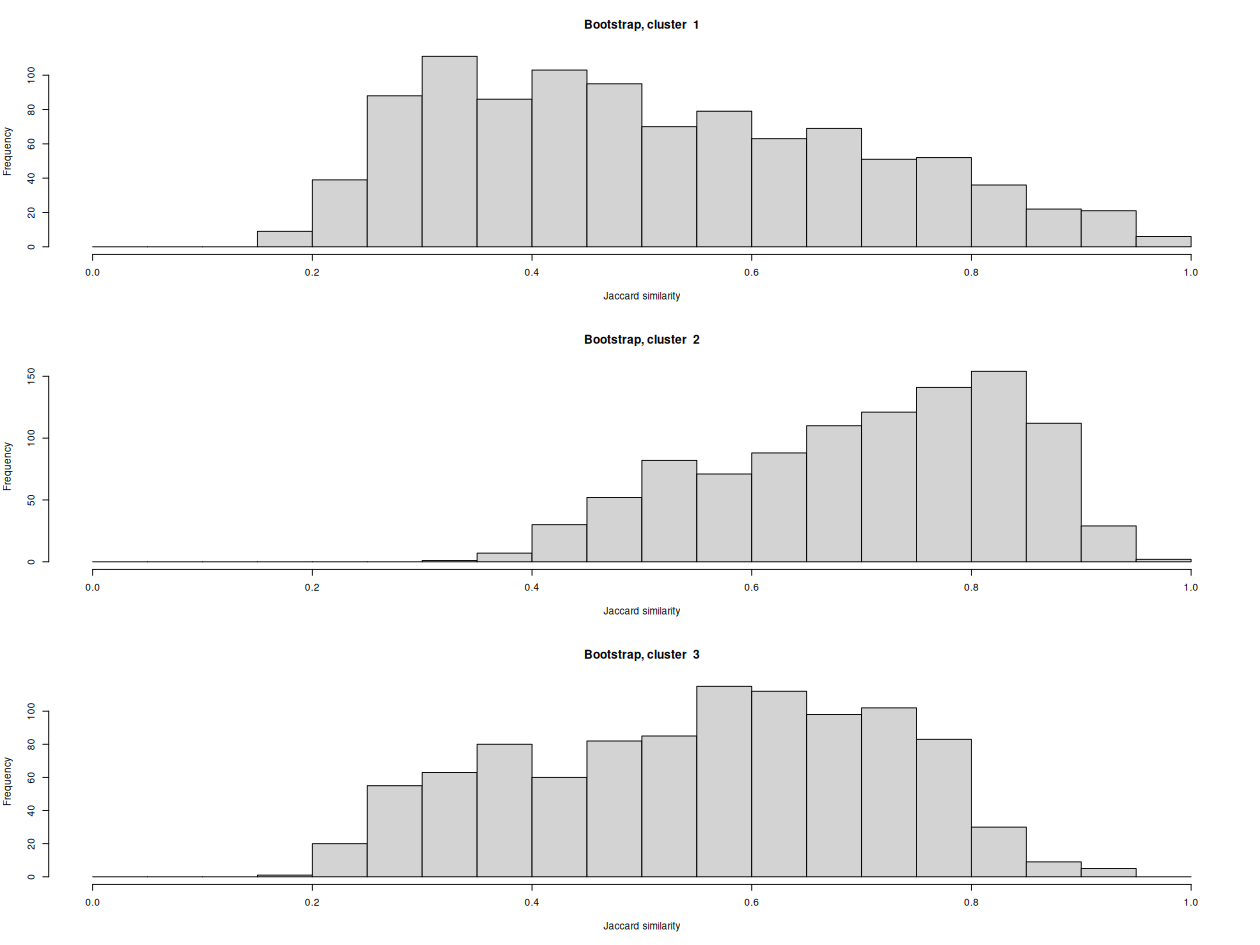

In [136]:
# Plotting the output 
par(mfrow = c(4, 1))
plot(cboot)

In [137]:
cluster_assignments <- as.factor(cboot$result$partition)

#### CART
Pour predire druggabilite avec CART dans df on doit avoir le score (score reel dans train et predit dans test)

In [138]:
data_cart <- train_set
data_cart$Shape <- file_na[train_idx, 23]
data_cart$cluster <- cluster_assignments

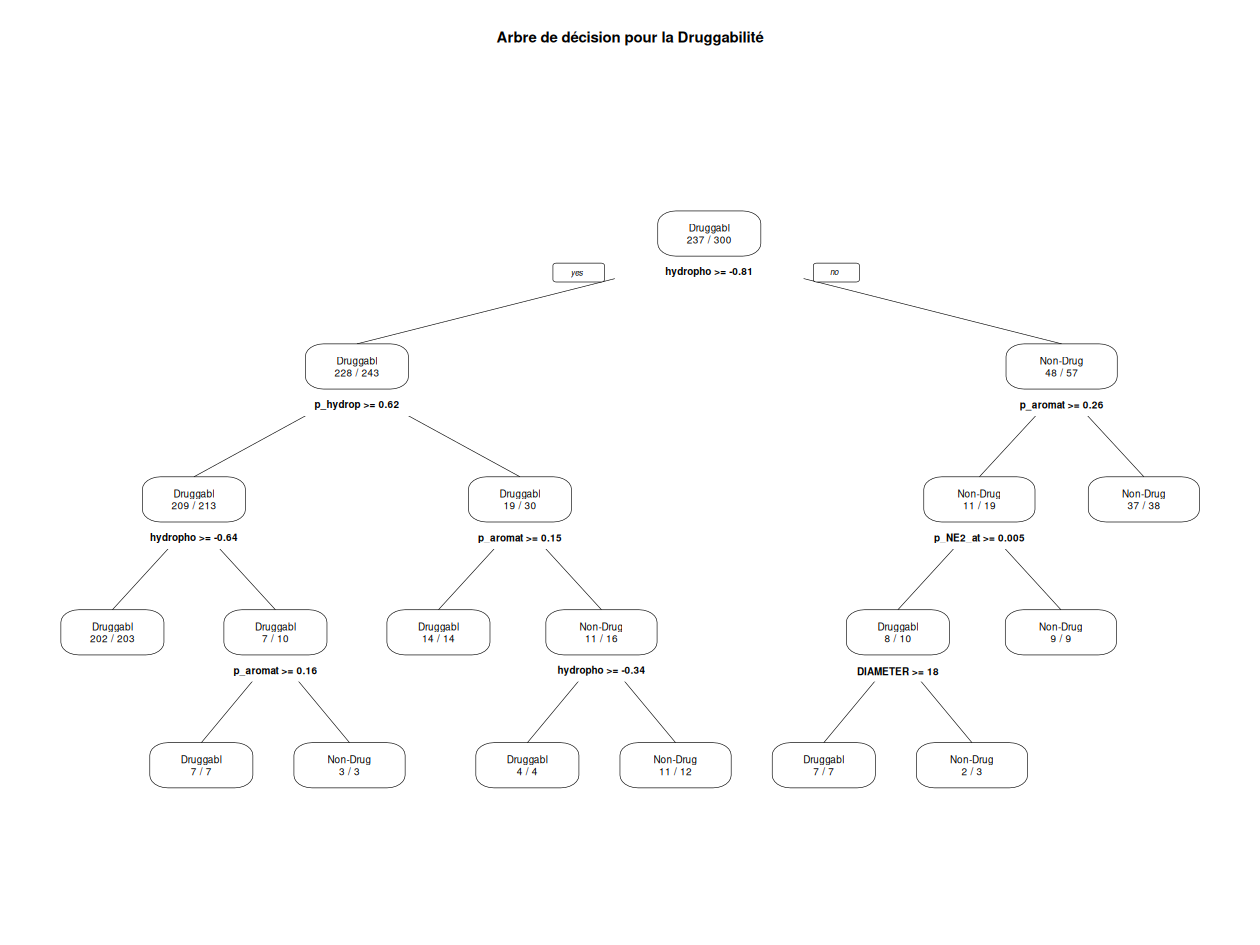


Classification tree:
rpart(formula = druggable ~ ., data = data_cart, method = "class", 
    control = rpart.control(minsplit = 5))

Variables actually used in tree construction:
[1] DIAMETER_HULL          hydrophobic_kyte       p_aromatic_residues    p_hydrophobic_residues p_NE2_atom            

Root node error: 63/300 = 0.21

n= 300 

        CP nsplit rel error  xerror     xstd
1 0.619048      0  1.000000 1.00000 0.111981
2 0.047619      1  0.380952 0.57143 0.089341
3 0.023810      6  0.126984 0.44444 0.079976
4 0.015873      8  0.079365 0.44444 0.079976
5 0.010000      9  0.063492 0.44444 0.079976


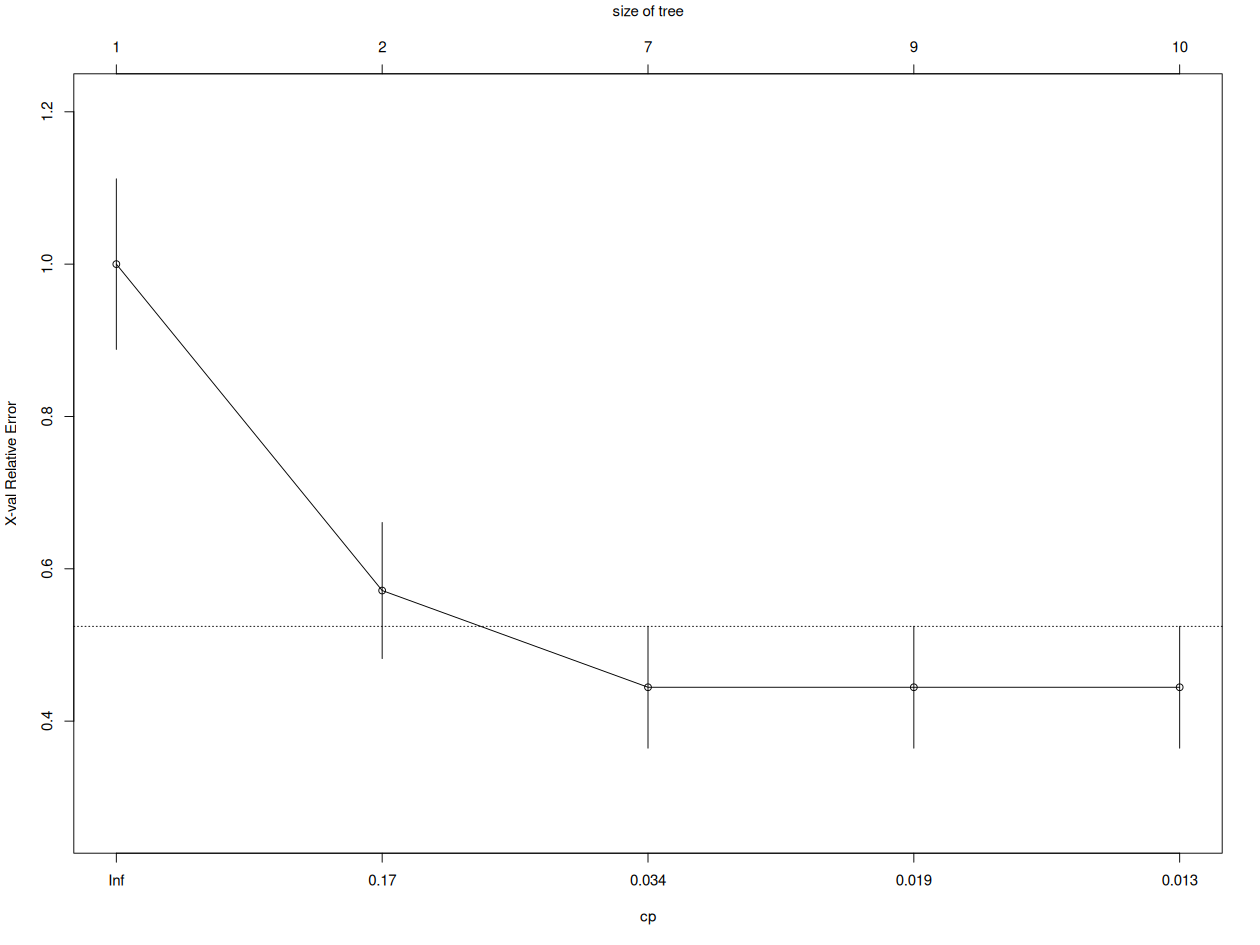

In [139]:
# Train the CART decision tree
cart_model <- rpart(
  druggable ~ ., 
  data = data_cart, 
  method = "class", 
  control = rpart.control(minsplit = 5)
)

# Plot the interpretable decision tree
prp(cart_model, type = 2, extra = 2, main = "Arbre de décision pour la Druggabilité")
printcp(cart_model)
plotcp(cart_model)
#rpart.plot(cart_model, main = "CART Profiling of Resampled PCA-hclust Clusters", extra = 104)

L’argument extra=2 : permet de préciser pour chaque noeud/feuille le taux de classification en donnant :

    le nombre de classifications correctes (valeur à gauche du “/”)
    le nombre d’observations dans le noeud (valeur à droite du “/”).

Analysez ce modèle ? Quels sont les descripteurs qui sont impliqués dans le modèle